# Pitcher IL Analysis — 2021–2025

Builds a per-game time-series dataset of **pitch metrics + outcome metrics** for all qualified pitchers
across every season 2021–2025, then enriches each game row with injury context: if a pitcher went on
the 10/15-day or 60-day IL after that outing, the row is tagged with the IL type, placement date, and
days between the outing and the placement.

---

## Sections
1. **Setup** — imports, config, cache directory
2. **Metric helpers** — per-game computation logic (mirrors `backend/compute.py`)
3. **Pitcher roster** — all qualified pitchers 2021–2025 with MLBAM IDs
4. **Statcast data** — per-pitcher per-season fetch + per-game aggregation (disk-cached)
5. **IL transaction data** — MLB Stats API, filter to initial IL placements
6. **IL enrichment** — tag each pre-IL outing with injury context
7. **Export** — save `pitcher_game_stats_with_il.parquet` + CSV
8. **Exploration** — summary comparisons and example queries

> **Runtime note:** First run fetches Statcast data for ~300 pitchers × 5 seasons via `statcast_pitcher()`.
> This takes **30–90 minutes** depending on network speed. Every subsequent run reads from disk cache
> (a few seconds). Progress is saved after each pitcher-season — safe to interrupt and resume.

In [1]:
import sys
import time
import json
import warnings
import requests
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import date, timedelta
from pybaseball import pitching_stats, playerid_reverse_lookup, statcast_pitcher

try:
    from tqdm import tqdm
    HAS_TQDM = True
except ImportError:
    def tqdm(iterable, **kwargs):
        desc  = kwargs.get("desc", "")
        total = kwargs.get("total", None)
        items = list(iterable)
        n     = len(items)
        for i, item in enumerate(items):
            print(f"\r{desc} {i+1}/{n}", end="", flush=True)
            yield item
        print()
    HAS_TQDM = False

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:.3f}".format)

print(f"Python {sys.version.split()[0]}  |  pandas {pd.__version__}  |  numpy {np.__version__}")
print(f"tqdm available: {HAS_TQDM}")

Python 3.11.0  |  pandas 3.0.1  |  numpy 2.4.2
tqdm available: True


In [2]:
# ── Configuration ─────────────────────────────────────────────────────────────

SEASONS           = [2021, 2022, 2023, 2024, 2025]
MIN_G             = 3          # min games in a season to include a pitcher
MIN_IP            = 5          # min IP in a season — low to catch pitchers who got hurt early
MAX_DAYS_PRE_IL   = 45         # only tag an outing if IL placement is ≤ this many days later
API_SLEEP         = 0.5        # seconds between pybaseball calls
CHUNK_SIZE        = 50         # batch size for playerid_reverse_lookup

# Disk cache — all intermediate files land here
CACHE_DIR = Path("notebook_cache")
CACHE_DIR.mkdir(exist_ok=True)
(CACHE_DIR / "statcast").mkdir(exist_ok=True)
(CACHE_DIR / "game_logs").mkdir(exist_ok=True)

print(f"Cache directory : {CACHE_DIR.resolve()}")
print(f"Seasons         : {SEASONS}")
print(f"Min G / Min IP  : {MIN_G} / {MIN_IP}")

Cache directory : /home/jonnym/Desktop/Baseball_2026/Fantasy_Analysis/pitching_against_average/notebook_cache
Seasons         : [2021, 2022, 2023, 2024, 2025]
Min G / Min IP  : 3 / 5


---
## 1 · Metric Computation Helpers

These functions mirror `backend/compute.py` so the notebook is fully self-contained.
All metrics are identical to what the app displays.

In [3]:
# ── Pitch mechanic columns to average per game ────────────────────────────────
PITCH_METRIC_COLS = [
    "release_speed", "release_spin_rate", "pfx_x", "pfx_z",
    "release_extension", "release_pos_x", "release_pos_z", "effective_speed",
]

# ── Outcome metric column names (computed, not direct averages) ───────────────
OUTCOME_METRIC_COLS = [
    "exit_velo", "gb_pct", "fb_pct", "bb_per_9", "k_per_9",
    "whiff_pct", "swstr_pct", "chase_pct", "hhr_pct", "barrel_pct",
    "fps_pct", "zone_pct", "iz_whiff_pct", "oz_whiff_pct",
    "two_strike_whiff_pct", "rp_consistency",
]

# ── Pitch description sets ────────────────────────────────────────────────────
_SWSTR_DESC = {"swinging_strike", "swinging_strike_blocked", "foul_tip"}
_SWING_DESC = _SWSTR_DESC | {
    "foul", "foul_bunt", "foul_pitchout",
    "hit_into_play", "hit_into_play_no_out", "hit_into_play_score",
}
_FPS_DESC = {
    "called_strike", "swinging_strike", "swinging_strike_blocked",
    "foul_tip", "foul", "foul_bunt", "foul_pitchout",
}
_OUT_EVENTS_1 = {"strikeout", "field_out", "fielders_choice_out", "force_out", "sac_fly", "sac_bunt"}
_OUT_EVENTS_2 = {
    "grounded_into_double_play", "strikeout_double_play",
    "sac_fly_double_play", "sac_bunt_double_play", "double_play",
}
_OUT_EVENTS_3 = {"triple_play"}

PITCH_TYPE_LABELS = {
    "FF": "4-Seam FB", "SI": "Sinker",   "FC": "Cutter",      "SL": "Slider",
    "CU": "Curveball", "KC": "Kn. Curve","CH": "Changeup",    "FS": "Splitter",
    "ST": "Sweeper",   "SV": "Slurve",   "KN": "Knuckleball", "EP": "Eephus",
}

print("Constants defined.")

Constants defined.


In [4]:
def compute_game_row(gdf: pd.DataFrame) -> dict:
    """
    Aggregate one game's worth of Statcast pitch-level data into a single
    per-game row with pitch mechanics + all outcome metrics.
    Returns an empty dict if gdf is empty.
    """
    n = len(gdf)
    if n == 0:
        return {}

    # ── Pitch mechanics: simple means (full aggregate) ────────────────────────
    row: dict = {
        col: float(gdf[col].mean()) if col in gdf.columns else np.nan
        for col in PITCH_METRIC_COLS
    }

    # ── Per-pitch-type release speed + spin rate ──────────────────────────────
    if "pitch_type" in gdf.columns:
        for pt in PITCH_TYPE_LABELS:
            pt_df = gdf[gdf["pitch_type"] == pt]
            row[f"release_speed_{pt}"] = (
                float(pt_df["release_speed"].mean())
                if len(pt_df) > 0 and "release_speed" in pt_df.columns
                else np.nan
            )
            row[f"release_spin_rate_{pt}"] = (
                float(pt_df["release_spin_rate"].mean())
                if len(pt_df) > 0 and "release_spin_rate" in pt_df.columns
                else np.nan
            )

    # ── Counting stats ────────────────────────────────────────────────────────
    pa_df  = gdf[gdf["events"].notna()]
    tbf    = len(pa_df)
    walks  = int(pa_df["events"].isin(["walk", "intent_walk"]).sum())
    ks     = int(pa_df["events"].isin(["strikeout", "strikeout_double_play"]).sum())
    hrs    = int(pa_df["events"].isin(["home_run"]).sum())
    outs   = (
        int(pa_df["events"].isin(_OUT_EVENTS_1).sum())
        + int(pa_df["events"].isin(_OUT_EVENTS_2).sum()) * 2
        + int(pa_df["events"].isin(_OUT_EVENTS_3).sum()) * 3
    )
    ip = outs / 3 if outs > 0 else np.nan

    # ── Swing / whiff ─────────────────────────────────────────────────────────
    n_swstr  = int(gdf["description"].isin(_SWSTR_DESC).sum())
    n_swings = int(gdf["description"].isin(_SWING_DESC).sum())

    # ── Zone / chase ──────────────────────────────────────────────────────────
    in_zone    = gdf["zone"].between(1, 9, inclusive="both")
    out_zone   = ~in_zone & gdf["zone"].notna()
    n_out_zone = int(out_zone.sum())
    n_chase    = int(gdf.loc[out_zone, "description"].isin(_SWING_DESC).sum())

    iz_swings = int(gdf.loc[in_zone,  "description"].isin(_SWING_DESC).sum())
    iz_swstr  = int(gdf.loc[in_zone,  "description"].isin(_SWSTR_DESC).sum())
    oz_swings = int(gdf.loc[out_zone, "description"].isin(_SWING_DESC).sum())
    oz_swstr  = int(gdf.loc[out_zone, "description"].isin(_SWSTR_DESC).sum())

    two_k_mask = gdf["strikes"] == 2
    ts_swings  = int(gdf.loc[two_k_mask, "description"].isin(_SWING_DESC).sum())
    ts_swstr   = int(gdf.loc[two_k_mask, "description"].isin(_SWSTR_DESC).sum())

    # ── First-pitch strike ────────────────────────────────────────────────────
    fp_mask = (gdf["balls"] == 0) & (gdf["strikes"] == 0)
    n_fp    = int(fp_mask.sum())
    n_fps   = int(gdf.loc[fp_mask, "description"].isin(_FPS_DESC).sum())

    # ── Batted ball ───────────────────────────────────────────────────────────
    bip_speed  = (gdf.loc[gdf["launch_speed"].notna(), "launch_speed"]
                  if "launch_speed" in gdf.columns else pd.Series(dtype=float))
    n_bip      = len(bip_speed)
    total_bip  = int(gdf["bb_type"].notna().sum())

    # ── Barrel ────────────────────────────────────────────────────────────────
    if "launch_speed_angle" in gdf.columns:
        barrel_count = int((gdf["launch_speed_angle"].fillna("").str.lower() == "barrel").sum())
    elif "launch_angle" in gdf.columns and "launch_speed" in gdf.columns:
        barrel_count = int(((gdf["launch_speed"] >= 98) & gdf["launch_angle"].between(26, 30)).sum())
    else:
        barrel_count = 0

    # ── Release-point consistency ─────────────────────────────────────────────
    rp_std_x = gdf["release_pos_x"].std() if "release_pos_x" in gdf.columns else np.nan
    rp_std_z = gdf["release_pos_z"].std() if "release_pos_z" in gdf.columns else np.nan
    rp_cons  = ((rp_std_x + rp_std_z) / 2
                if not (pd.isna(rp_std_x) or pd.isna(rp_std_z)) else np.nan)

    row.update({
        # Game context
        "n_pitches":             n,
        "tbf":                   tbf,
        "ip":                    ip,
        "k":                     ks,
        "bb":                    walks,
        "hr":                    hrs,
        # Outcome metrics
        "exit_velo":             bip_speed.mean() if n_bip else np.nan,
        "gb_pct":                (gdf["bb_type"] == "ground_ball").sum() / total_bip * 100 if total_bip else np.nan,
        "fb_pct":                (gdf["bb_type"] == "fly_ball").sum()    / total_bip * 100 if total_bip else np.nan,
        "bb_per_9":              walks / tbf * 27 if tbf else np.nan,
        "k_per_9":               ks    / tbf * 27 if tbf else np.nan,
        "whiff_pct":             n_swstr / n_swings  * 100 if n_swings  else np.nan,
        "swstr_pct":             n_swstr / n         * 100,
        "chase_pct":             n_chase / n_out_zone * 100 if n_out_zone else np.nan,
        "hhr_pct":               (bip_speed >= 95).sum() / n_bip * 100 if n_bip else np.nan,
        "barrel_pct":            barrel_count / tbf * 100 if tbf else np.nan,
        "fps_pct":               n_fps / n_fp * 100 if n_fp else np.nan,
        "zone_pct":              int(in_zone.sum()) / n * 100,
        "iz_whiff_pct":          iz_swstr / iz_swings * 100 if iz_swings else np.nan,
        "oz_whiff_pct":          oz_swstr / oz_swings * 100 if oz_swings else np.nan,
        "two_strike_whiff_pct":  ts_swstr / ts_swings * 100 if ts_swings else np.nan,
        "rp_consistency":        rp_cons,
    })
    return row


def statcast_to_game_log(
    sc_df: pd.DataFrame,
    pitcher_name: str,
    mlbam_id: int,
    season: int,
) -> pd.DataFrame:
    """
    Convert raw Statcast pitch-level data for one pitcher-season into
    one row per game appearance with all metrics computed.
    """
    if sc_df.empty:
        return pd.DataFrame()

    sc_df = sc_df.copy()
    sc_df["game_date"] = pd.to_datetime(sc_df["game_date"]).dt.date

    rows = []
    for gd, gdf in sc_df.groupby("game_date"):
        r = compute_game_row(gdf)
        if not r:
            continue
        r["game_date"]    = gd
        r["pitcher_name"] = pitcher_name
        r["mlbam_id"]     = mlbam_id
        r["season"]       = season
        # Also store top pitch type by usage
        if "pitch_type" in gdf.columns:
            pt_counts = gdf["pitch_type"].dropna().value_counts()
            r["primary_pitch"] = pt_counts.index[0] if not pt_counts.empty else np.nan
            r["primary_pitch_pct"] = pt_counts.iloc[0] / len(gdf) * 100 if not pt_counts.empty else np.nan
        rows.append(r)

    if not rows:
        return pd.DataFrame()

    df = pd.DataFrame(rows)
    df["game_date"] = pd.to_datetime(df["game_date"])
    return df.sort_values("game_date").reset_index(drop=True)


print("compute_game_row() and statcast_to_game_log() defined.")

---
## 2 · Pitcher Roster

Pull Fangraphs pitching stats for each season via `pybaseball.pitching_stats()`, filter to pitchers with
≥ `MIN_G` games and ≥ `MIN_IP` innings pitched (deliberately low to capture pitchers who got hurt early),
then resolve Fangraphs IDs → MLBAM IDs via `playerid_reverse_lookup()`.

Result is cached to `notebook_cache/pitcher_roster.parquet`.

In [5]:
ROSTER_CACHE = CACHE_DIR / "pitcher_roster.parquet"


def build_pitcher_roster(
    seasons: list[int] = SEASONS,
    min_g: int = MIN_G,
    min_ip: float = MIN_IP,
    force: bool = False,
) -> pd.DataFrame:
    """
    Returns a DataFrame with one row per unique pitcher, columns:
      IDfg, Name, Team, IP, G, GS, best_season, mlbam_id
    """
    if ROSTER_CACHE.exists() and not force:
        print(f"Loading roster from cache: {ROSTER_CACHE}")
        return pd.read_parquet(ROSTER_CACHE)

    print("Fetching pitching stats from Fangraphs…")
    season_dfs = []
    for s in seasons:
        try:
            df = pitching_stats(s, qual=1)   # qual=1 → at least 1 TBF; we filter ourselves
            df["season"] = s
            season_dfs.append(df[["IDfg", "Name", "Team", "IP", "G", "GS", "season"]])
            print(f"  {s}: {len(df):,} pitchers")
        except Exception as e:
            print(f"  {s}: FAILED — {e}")

    if not season_dfs:
        raise RuntimeError("Could not fetch pitching stats for any season.")

    combined = pd.concat(season_dfs, ignore_index=True)
    combined["IP"] = pd.to_numeric(combined["IP"], errors="coerce").fillna(0)
    combined["G"]  = pd.to_numeric(combined["G"],  errors="coerce").fillna(0)
    combined["GS"] = pd.to_numeric(combined["GS"], errors="coerce").fillna(0)

    qualified = combined[
        (combined["G"]  >= min_g) &
        (combined["IP"] >= min_ip)
    ].copy()

    # Keep one row per pitcher — the most recent season's metadata
    unique = (
        qualified
        .sort_values("season", ascending=False)
        .drop_duplicates("IDfg", keep="first")
        .rename(columns={"season": "best_season"})
        .reset_index(drop=True)
    )
    print(f"\nUnique qualified pitchers: {len(unique):,}")

    # ── Resolve MLBAM IDs in chunks of CHUNK_SIZE ─────────────────────────────
    idfg_list = unique["IDfg"].astype(int).tolist()
    mlbam_map: dict[int, int] = {}
    print(f"Resolving MLBAM IDs ({len(idfg_list)} pitchers, chunks of {CHUNK_SIZE})…")

    for start in range(0, len(idfg_list), CHUNK_SIZE):
        chunk = idfg_list[start : start + CHUNK_SIZE]
        try:
            res = playerid_reverse_lookup(chunk, key_type="fangraphs")
            if not res.empty:
                for _, r in res.iterrows():
                    fg  = r.get("key_fangraphs")
                    mlb = r.get("key_mlbam")
                    if pd.notna(fg) and pd.notna(mlb):
                        mlbam_map[int(fg)] = int(mlb)
        except Exception as e:
            print(f"  Chunk {start//CHUNK_SIZE + 1} error: {e}")
        time.sleep(API_SLEEP)
        end = min(start + CHUNK_SIZE, len(idfg_list))
        print(f"  Resolved {end}/{len(idfg_list)}", end="\r")

    print()
    unique["mlbam_id"] = unique["IDfg"].astype(int).map(mlbam_map)
    n_missing = unique["mlbam_id"].isna().sum()
    if n_missing:
        print(f"  Warning: {n_missing} pitchers could not be resolved to MLBAM IDs — dropping them.")
    unique = unique.dropna(subset=["mlbam_id"]).copy()
    unique["mlbam_id"] = unique["mlbam_id"].astype(int)

    unique.to_parquet(ROSTER_CACHE, index=False)
    print(f"\n✓ Roster saved: {len(unique):,} pitchers → {ROSTER_CACHE}")
    return unique


print("build_pitcher_roster() defined.")

build_pitcher_roster() defined.


In [6]:
roster = build_pitcher_roster()
print(f"\nRoster: {len(roster):,} pitchers")
roster.head(10)

Fetching pitching stats from Fangraphs…
  2021: 885 pitchers
  2022: 861 pitchers
  2023: 851 pitchers
  2024: 840 pitchers
  2025: 864 pitchers

Unique qualified pitchers: 1,385
Resolving MLBAM IDs (1385 pitchers, chunks of 50)…
Gathering player lookup table. This may take a moment.
Finished gathering player lookup table with 25901 players.
  name_last name_first  key_mlbam key_retro  key_bbref  key_fangraphs  \
0   Bradley        Jed     605152  bradj002  bradlje01          13166   
1   Barrios     Manuel     110625  barrm002  barrima01        1000605   
2    Martin      Frank     118336  martf102  martifr01        1008165   
3    Browne      Byron     111603  browb101  brownby01        1001500   
4   Jackson       John     800935  jackj702        NaN             -1   

   mlb_played_first  mlb_played_last  
0          2016.000         2016.000  
1          1997.000         1998.000  
2          1897.000         1899.000  
3          1965.000         1972.000  
4               NaN   

,IDfg,Name,Team,IP,G,GS,best_season,mlbam_id
0,14916,Jon Gray,TEX,14.000,6,0,2025,592351
1,23135,Eduardo Salazar,WSN,29.000,30,0,2025,674285
3,17490,Genesis Cabrera,- - -,42.200,40,0,2025,650893
4,17874,Nestor Cortes,- - -,34.100,8,8,2025,641482
5,15552,Chad Green,TOR,43.200,45,0,2025,643338
6,20548,Bowden Francis,TOR,64.000,14,14,2025,670102
8,19362,Keegan Akin,BAL,63.100,64,3,2025,669211
11,26079,Beau Brieske,DET,22.000,22,1,2025,689225
12,25679,Kevin Kelly,TBR,39.200,41,0,2025,687330
13,21453,Konnor Pilkington,WSN,28.100,32,0,2025,663455


---
## 3 · Statcast Data Fetch

For every pitcher × season combination, calls `statcast_pitcher()` and writes the raw pitch-level
Statcast data to `notebook_cache/statcast/<mlbam_id>_<season>.parquet`.

Then aggregates each raw file into per-game rows using `statcast_to_game_log()` and saves to
`notebook_cache/game_logs/<mlbam_id>_<season>.parquet`.

**Skip logic:** if a `.parquet` file already exists for a given pitcher-season, it is skipped.
Re-run is safe and picks up where it left off.

In [7]:
def fetch_and_cache_statcast(
    mlbam_id: int,
    season: int,
    force: bool = False,
) -> pd.DataFrame:
    """
    Fetch raw Statcast data for one pitcher-season.
    Reads from disk cache if available; writes to disk on first fetch.
    Returns an empty DataFrame if no data found.
    """
    cache_file = CACHE_DIR / "statcast" / f"{mlbam_id}_{season}.parquet"
    if cache_file.exists() and not force:
        return pd.read_parquet(cache_file)

    end_dt = date.today() if season == date.today().year else date(season, 11, 30)
    try:
        df = statcast_pitcher(f"{season}-02-15", end_dt.strftime("%Y-%m-%d"), mlbam_id)
    except Exception:
        df = pd.DataFrame()

    if df is None or df.empty:
        pd.DataFrame().to_parquet(cache_file, index=False)
        return pd.DataFrame()

    df.to_parquet(cache_file, index=False)
    return df


def run_statcast_fetch(
    roster: pd.DataFrame,
    seasons: list[int] = SEASONS,
    force: bool = False,
    sleep: float = API_SLEEP,
) -> list[tuple]:
    """
    Main fetch loop. For each pitcher × season:
      1. Fetch raw Statcast (cached).
      2. Compute per-game log.
      3. Save game log parquet.
    Returns a list of (mlbam_id, season, error) tuples for any failures.
    """
    pairs = [
        (int(row["mlbam_id"]), row["Name"], s)
        for _, row in roster.iterrows()
        for s in seasons
    ]
    total   = len(pairs)
    errors  = []
    skipped = 0
    fetched = 0

    for mlbam_id, name, season in tqdm(pairs, desc="Pitcher-seasons", total=total):
        log_file = CACHE_DIR / "game_logs" / f"{mlbam_id}_{season}.parquet"

        if log_file.exists() and not force:
            skipped += 1
            continue

        try:
            sc_df    = fetch_and_cache_statcast(mlbam_id, season, force=force)
            game_log = statcast_to_game_log(sc_df, name, mlbam_id, season)
        except Exception as e:
            errors.append((mlbam_id, season, str(e)))
            pd.DataFrame().to_parquet(log_file, index=False)
            continue

        if game_log.empty:
            pd.DataFrame().to_parquet(log_file, index=False)
        else:
            game_log.to_parquet(log_file, index=False)

        fetched += 1
        time.sleep(sleep)

    print(f"Done. Fetched: {fetched}  |  Skipped (cached): {skipped}  |  Errors: {len(errors)}")
    return errors


print("Statcast fetch helpers defined.")

Statcast fetch helpers defined.


In [10]:
# ── Run the fetch ─────────────────────────────────────────────────────────────
# First run: 30–90 min depending on network speed and roster size.
# Subsequent runs: skips all cached files, completes in seconds.

print(f"Total pitcher × season pairs: {len(roster) * len(SEASONS):,}")
print("Fetching… (progress bar shows pitcher-seasons processed)\n")

errors = run_statcast_fetch(roster, seasons=SEASONS, force=False, sleep=API_SLEEP)

if errors:
    print("\nFailed pitcher-seasons:")
    for mlbam_id, season, msg in errors[:20]:
        print(f"  mlbam={mlbam_id}  season={season}  err={msg}")

Total pitcher × season pairs: 5,825
Fetching… (progress bar shows pitcher-seasons processed)



Gathering Player Data


Gathering Player Data


Gathering Player Data


Gathering Player Data


...

Gathering Player Data


Gathering Player Data


Gathering Player Data


Pitcher-seasons: 100%|██████████| 5825/5825 [5:25:22<00:00,  3.35s/it]

Done. Fetched: 5568  |  Skipped (cached): 0  |  Errors: 257

Failed pitcher-seasons:
  mlbam=650893  season=2023  err=Can only use .str accessor with string values, not floating
  mlbam=643338  season=2024  err=Can only use .str accessor with string values, not floating
  mlbam=669211  season=2023  err=Can only use .str accessor with string values, not floating
  mlbam=669211  season=2024  err=Can only use .str accessor with string values, not floating
  mlbam=669211  season=2025  err=Can only use .str accessor with string values, not floating
  mlbam=573009  season=2024  err=Can only use .str accessor with string values, not floating
  mlbam=608371  season=2023  err=Can only use .str accessor with string values, not floating
  mlbam=608371  season=2024  err=Can only use .str accessor with string values, not floating
  mlbam=547184  season=2024  err=Can only use .str accessor with string values, not floating
  mlbam=621363  season=2023  err=Can only use .str accessor with string values

---
## 4 · Build Master Game Log

Concatenate all per-pitcher per-season game log files into one master DataFrame.
Cached to `notebook_cache/master_game_log.parquet`.

In [11]:
MASTER_CACHE = CACHE_DIR / "master_game_log.parquet"


def build_master_game_log(
    roster: pd.DataFrame,
    seasons: list[int] = SEASONS,
    force: bool = False,
) -> pd.DataFrame:
    """Combine all per-pitcher per-season game logs into one master DataFrame."""
    if MASTER_CACHE.exists() and not force:
        print(f"Loading master game log from cache: {MASTER_CACHE}")
        return pd.read_parquet(MASTER_CACHE)

    print("Combining game log files…")
    all_logs = []
    missing  = []

    for _, row in roster.iterrows():
        for s in seasons:
            log_file = CACHE_DIR / "game_logs" / f"{int(row['mlbam_id'])}_{s}.parquet"
            if not log_file.exists():
                missing.append((row["Name"], s))
                continue
            try:
                df = pd.read_parquet(log_file)
                if not df.empty:
                    all_logs.append(df)
            except Exception:
                pass

    if missing:
        print(f"  Warning: {len(missing)} log files not found — run Step 3 first.")
    if not all_logs:
        raise RuntimeError("No game log files found. Run the Statcast fetch (Step 3) first.")

    master = pd.concat(all_logs, ignore_index=True)
    master["game_date"] = pd.to_datetime(master["game_date"])
    master = master.sort_values(["pitcher_name", "game_date"]).reset_index(drop=True)

    master.to_parquet(MASTER_CACHE, index=False)
    print(f"✓ Saved master game log → {MASTER_CACHE}")
    return master


print("build_master_game_log() defined.")

build_master_game_log() defined.


In [12]:
game_log = build_master_game_log(roster)

print(f"\nShape            : {game_log.shape}")
print(f"Unique pitchers  : {game_log['pitcher_name'].nunique():,}")
print(f"Date range       : {game_log['game_date'].min().date()} → {game_log['game_date'].max().date()}")
print(f"Seasons          : {sorted(game_log['season'].unique())}")
print(f"\nColumns:")
print(list(game_log.columns))
print()
game_log.head(3)

Combining game log files…
✓ Saved master game log → notebook_cache/master_game_log.parquet

Shape            : (103296, 36)
Unique pitchers  : 1,157
Date range       : 2021-02-28 → 2025-11-01
Seasons          : [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Columns:
['release_speed', 'release_spin_rate', 'pfx_x', 'pfx_z', 'release_extension', 'release_pos_x', 'release_pos_z', 'effective_speed', 'n_pitches', 'tbf', 'ip', 'k', 'bb', 'hr', 'exit_velo', 'gb_pct', 'fb_pct', 'bb_per_9', 'k_per_9', 'whiff_pct', 'swstr_pct', 'chase_pct', 'hhr_pct', 'barrel_pct', 'fps_pct', 'zone_pct', 'iz_whiff_pct', 'oz_whiff_pct', 'two_strike_whiff_pct', 'rp_consistency', 'game_date', 'pitcher_name', 'mlbam_id', 'season', 'primary_pitch', 'primary_pitch_pct']



,release_speed,release_spin_rate,pfx_x,pfx_z,release_extension,release_pos_x,release_pos_z,effective_speed,n_pitches,tbf,ip,k,bb,hr,exit_velo,gb_pct,fb_pct,bb_per_9,k_per_9,whiff_pct,swstr_pct,chase_pct,hhr_pct,barrel_pct,fps_pct,zone_pct,iz_whiff_pct,oz_whiff_pct,two_strike_whiff_pct,rp_consistency,game_date,pitcher_name,mlbam_id,season,primary_pitch,primary_pitch_pct
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6,3,0.667,1,0,0,NaN,50.000,0.000,0.000,9.000,50.000,33.333,NaN,NaN,0.000,66.667,0.000,NaN,NaN,100.000,NaN,2021-03-14,A.J. Alexy,669935,2021,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12,6,1.000,0,2,0,NaN,50.000,0.000,9.000,0.000,0.000,0.000,NaN,NaN,0.000,0.000,0.000,NaN,NaN,NaN,NaN,2021-03-28,A.J. Alexy,669935,2021,NaN,NaN
2,89.322,2130.444,-0.256,1.061,6.653,-1.106,5.982,89.899,81,18,4.667,4,3,0,75.542,18.182,36.364,4.500,6.000,30.556,13.580,20.408,16.667,0.000,38.889,39.506,30.769,30.000,28.571,0.079,2021-08-30,A.J. Alexy,669935,2021,FF,64.198


---
## 5 · IL Transaction Data

Fetches all transactions from the **MLB Stats API** for each season and filters to **initial IL placements**:
- `"placed ... on the 10-day injured list"` (standard short-term IL)
- `"placed ... on the 15-day injured list"` (historical / retroactive placements)
- `"placed ... on the 60-day injured list"` (long-term, usually surgery/serious injury)

**Transfers** (`"transferred from X-day to Y-day"`) are kept separately but not used as the primary
enrichment trigger — the initial placement date is what matters for identifying the pre-IL outing.

All transactions use `typeCode = "SC"` (Status Change); we distinguish by parsing the `description`.

Cached to `notebook_cache/il_transactions.parquet`.

In [13]:
IL_CACHE    = CACHE_DIR / "il_transactions.parquet"
MLB_API_URL = "https://statsapi.mlb.com/api/v1/transactions"


def _parse_il_type(description: str) -> str | None:
    """
    Parse the IL type from a transaction description string.
    Returns '60-day', '15-day', '10-day', or None if not an IL placement.
    """
    d = description.lower()
    if "injured list" not in d:
        return None
    if "60-day" in d or "60 day" in d:
        return "60-day"
    if "15-day" in d or "15 day" in d:
        return "15-day"
    if "10-day" in d or "10 day" in d:
        return "10-day"
    return None


def _is_initial_placement(description: str) -> bool:
    """
    True for initial IL placements ("placed on").
    False for transfers ("transferred from") and reinstatements ("reinstated from").
    """
    d = description.lower()
    # Keep transfers to 60-day as well — serious escalation worth flagging
    if "transferred" in d and "to the 60-day" in d:
        return True
    if "transferred" in d or "reinstated" in d:
        return False
    if "placed" in d:
        return True
    return False


def fetch_il_transactions(
    seasons: list[int] = SEASONS,
    force: bool = False,
) -> pd.DataFrame:
    """
    Fetch all IL placement transactions from the MLB Stats API for the given seasons.
    Returns a DataFrame with one row per IL placement event.
    Columns: mlbam_id, player_name, il_type, il_date, is_transfer_to_60,
             injury_note, raw_description, season
    """
    if IL_CACHE.exists() and not force:
        print(f"Loading IL transactions from cache: {IL_CACHE}")
        return pd.read_parquet(IL_CACHE)

    print("Fetching IL transactions from MLB Stats API…")
    raw_transactions: list[dict] = []

    for season in seasons:
        params = {
            "startDate": f"{season}-02-01",
            "endDate":   f"{season}-12-15",
            "sportId":   1,
        }
        try:
            resp = requests.get(MLB_API_URL, params=params, timeout=30)
            resp.raise_for_status()
            txns = resp.json().get("transactions", [])
            raw_transactions.extend(txns)
            print(f"  {season}: {len(txns):,} total transactions fetched")
        except Exception as e:
            print(f"  {season}: FAILED — {e}")
        time.sleep(0.3)

    print(f"\nTotal raw transactions: {len(raw_transactions):,}")

    rows = []
    for t in raw_transactions:
        desc = t.get("description") or ""
        if "injured list" not in desc.lower():
            continue
        if not _is_initial_placement(desc):
            continue

        il_type = _parse_il_type(desc)
        if il_type is None:
            continue

        person   = t.get("person") or {}
        mlbam_id = person.get("id")
        if not mlbam_id:
            continue

        date_str = t.get("date") or t.get("effectiveDate")
        if not date_str:
            continue

        # Extract injury note — text after the last period or sentence break
        # e.g. "...placed on 10-day IL. Right shoulder inflammation."
        parts = desc.strip().rstrip(".").split(".")
        injury_note = parts[-1].strip() if len(parts) > 1 else ""

        rows.append({
            "mlbam_id":          int(mlbam_id),
            "player_name":       person.get("fullName", ""),
            "il_type":           il_type,
            "il_date":           pd.to_datetime(date_str, errors="coerce"),
            "is_transfer_to_60": "transferred" in desc.lower() and "60-day" in desc.lower(),
            "injury_note":       injury_note,
            "raw_description":   desc,
        })

    df = pd.DataFrame(rows)
    if df.empty:
        raise RuntimeError("No IL transactions parsed. Check filtering logic or API response.")

    df["il_date"] = pd.to_datetime(df["il_date"])
    df["season"]  = df["il_date"].dt.year

    # Deduplicate: same player + same IL date (can appear if API returns duplicates)
    df = df.drop_duplicates(subset=["mlbam_id", "il_date", "il_type"]).reset_index(drop=True)
    df = df.sort_values(["il_date", "player_name"]).reset_index(drop=True)

    df.to_parquet(IL_CACHE, index=False)
    print(f"\n✓ IL transactions saved: {len(df):,} rows → {IL_CACHE}")
    return df


print("fetch_il_transactions() defined.")

fetch_il_transactions() defined.


In [14]:
il_df = fetch_il_transactions()

print(f"\nShape          : {il_df.shape}")
print(f"Date range     : {il_df['il_date'].min().date()} → {il_df['il_date'].max().date()}")
print(f"\nIL type breakdown:")
print(il_df["il_type"].value_counts().to_string())
print(f"\nTransfers to 60-day (escalated injuries): {il_df['is_transfer_to_60'].sum()}")
print("\nSample rows:")
il_df[["player_name", "il_type", "il_date", "is_transfer_to_60", "injury_note"]].head(10)

Fetching IL transactions from MLB Stats API…
  2021: 16,107 total transactions fetched
  2022: 19,467 total transactions fetched
  2023: 16,725 total transactions fetched
  2024: 13,465 total transactions fetched
  2025: 15,788 total transactions fetched

Total raw transactions: 81,552

✓ IL transactions saved: 5,457 rows → notebook_cache/il_transactions.parquet

Shape          : (5457, 8)
Date range     : 2021-02-17 → 2025-11-06

IL type breakdown:
il_type
10-day    2522
15-day    1589
60-day    1346

Transfers to 60-day (escalated injuries): 668

Sample rows:


,player_name,il_type,il_date,is_transfer_to_60,injury_note
0,Colin Poche,60-day,2021-02-17,False,
1,Jalen Beeks,60-day,2021-02-17,False,Tommy John surgery
2,Jeff Brigham,60-day,2021-02-17,False,
3,John Brebbia,60-day,2021-02-17,False,Tommy John surgery
4,José Soriano,60-day,2021-02-17,False,
5,Kevin Plawecki,10-day,2021-02-17,False,
6,Kyle Ryan,10-day,2021-02-17,False,
7,Seranthony Domínguez,60-day,2021-02-17,False,Recovering from Tommy John surgery
8,Andrés Muñoz,60-day,2021-02-18,False,Recovery from Tommy John surgery
9,Chris Sale,60-day,2021-02-18,False,Tommy John surgery


In [15]:
# How many IL transactions match pitchers in our game log?
our_mlbam_ids = set(game_log["mlbam_id"].unique())
il_our_pitchers = il_df[il_df["mlbam_id"].isin(our_mlbam_ids)]

print(f"Total IL transactions       : {len(il_df):,}")
print(f"Matching our pitcher dataset: {len(il_our_pitchers):,} ({len(il_our_pitchers)/len(il_df)*100:.1f}%)")
print(f"Unique pitchers with IL data: {il_our_pitchers['mlbam_id'].nunique():,}")
print(f"\nBreakdown by IL type (pitchers only):")
print(il_our_pitchers["il_type"].value_counts().to_string())

Total IL transactions       : 5,457
Matching our pitcher dataset: 3,101 (56.8%)
Unique pitchers with IL data: 882

Breakdown by IL type (pitchers only):
il_type
15-day    1476
60-day     902
10-day     723


---
## 6 · IL Enrichment

For each IL placement that matches a pitcher in our dataset, find the **last game appearance**
before the IL date (within `MAX_DAYS_PRE_IL = 45` days). Tag that row with:

| Column | Description |
|---|---|
| `is_pre_il_outing` | `True` if this game was the last outing before an IL placement |
| `il_type` | `"10-day"`, `"15-day"`, or `"60-day"` |
| `il_placement_date` | Date the pitcher was placed on IL |
| `days_outing_to_il` | Calendar days between this outing and the IL placement |
| `is_transfer_to_60` | `True` if the 60-day entry was an escalation of a prior IL stint |
| `injury_note` | Free-text injury description from the transaction (e.g. "Right elbow inflammation") |

If a pitcher has **multiple IL stints**, each stint gets its own pre-IL outing tagged independently.

In [16]:
def enrich_with_il(
    game_log: pd.DataFrame,
    il_df: pd.DataFrame,
    max_days_pre_il: int = MAX_DAYS_PRE_IL,
) -> pd.DataFrame:
    """
    Tag each game row that was the pitcher's last outing before an IL placement.
    Multiple IL stints per pitcher are all tagged independently.
    """
    result = game_log.copy()

    # Initialize IL columns
    result["is_pre_il_outing"]  = False
    result["il_type"]           = pd.NA
    result["il_placement_date"] = pd.NaT
    result["days_outing_to_il"] = pd.NA
    result["is_transfer_to_60"] = pd.NA
    result["injury_note"]       = pd.NA

    # Build mlbam_id → DataFrame lookup (sorted by date)
    pitcher_games: dict[int, pd.DataFrame] = {
        int(mid): grp.sort_values("game_date")
        for mid, grp in result.groupby("mlbam_id")
    }

    our_ids       = set(pitcher_games.keys())
    relevant_il   = il_df[il_df["mlbam_id"].isin(our_ids)].copy()
    tagged_count  = 0

    for _, il_row in relevant_il.iterrows():
        mid      = int(il_row["mlbam_id"])
        il_date  = il_row["il_date"]
        il_type  = il_row["il_type"]
        cutoff   = il_date - pd.Timedelta(days=max_days_pre_il)

        grp = pitcher_games.get(mid)
        if grp is None:
            continue

        # Last outing strictly before the IL date and within the lookback window
        candidates = grp[
            (grp["game_date"] < il_date) &
            (grp["game_date"] >= cutoff)
        ]
        if candidates.empty:
            continue

        last_idx  = candidates["game_date"].idxmax()
        last_date = candidates.loc[last_idx, "game_date"]
        days_gap  = (il_date - last_date).days

        result.at[last_idx, "is_pre_il_outing"]  = True
        result.at[last_idx, "il_type"]            = il_type
        result.at[last_idx, "il_placement_date"]  = il_date
        result.at[last_idx, "days_outing_to_il"]  = int(days_gap)
        result.at[last_idx, "is_transfer_to_60"]  = bool(il_row["is_transfer_to_60"])
        result.at[last_idx, "injury_note"]         = il_row["injury_note"]
        tagged_count += 1

    n_tagged = int(result["is_pre_il_outing"].sum())
    print(f"IL placements matched: {len(relevant_il):,}")
    print(f"Pre-IL outings tagged: {n_tagged:,}  (unique game rows with is_pre_il_outing=True)")
    print(f"  → {tagged_count - n_tagged} overlap cases (same game tagged by multiple IL stints)")
    return result


print("enrich_with_il() defined.")

enrich_with_il() defined.


In [17]:
game_log_il = enrich_with_il(game_log, il_df)

print(f"\nFinal dataset shape  : {game_log_il.shape}")
print(f"Total game rows      : {len(game_log_il):,}")
print(f"Pre-IL outing rows   : {game_log_il['is_pre_il_outing'].sum():,}")
print(f"\nIL type breakdown (tagged rows):")
print(game_log_il[game_log_il["is_pre_il_outing"]]["il_type"].value_counts().to_string())
print()

# Preview tagged rows
sample_cols = [
    "pitcher_name", "game_date", "season", "ip", "n_pitches",
    "release_speed", "whiff_pct", "k_per_9",
    "il_type", "il_placement_date", "days_outing_to_il", "injury_note"
]
game_log_il[game_log_il["is_pre_il_outing"]][sample_cols].head(10)

IL placements matched: 3,101
Pre-IL outings tagged: 1,975  (unique game rows with is_pre_il_outing=True)
  → 455 overlap cases (same game tagged by multiple IL stints)

Final dataset shape  : (103296, 42)
Total game rows      : 103,296
Pre-IL outing rows   : 1,975

IL type breakdown (tagged rows):
il_type
15-day    981
10-day    505
60-day    489



,pitcher_name,game_date,season,ip,n_pitches,release_speed,whiff_pct,k_per_9,il_type,il_placement_date,days_outing_to_il,injury_note
26,A.J. Cole,2021-05-27,2021,1.000,16,90.181,22.222,5.400,60-day,2021-06-12,16,Left oblqiey strain
151,A.J. Minter,2023-07-08,2023,0.333,9,91.700,0.000,27.000,15-day,2023-07-15,7,Left shoulder inflammation
198,A.J. Minter,2025-04-26,2025,0.333,9,93.922,0.000,27.000,60-day,2025-05-01,5,Left lat strain
202,A.J. Puk,2021-04-05,2021,3.333,65,91.588,26.087,7.714,10-day,2021-04-08,3,Left biceps strain
234,A.J. Puk,2023-05-10,2023,1.000,16,91.875,44.444,13.500,15-day,2023-05-13,3,Left elbow nerve irritation
294,A.J. Puk,2025-04-17,2025,1.000,21,94.186,20.000,6.750,60-day,2025-05-01,14,Left elbow inflammation
309,AJ Smith-Shawver,2024-05-23,2024,4.333,87,89.514,20.930,6.000,15-day,2024-05-24,1,Strained left oblique muscle
323,AJ Smith-Shawver,2025-05-22,2025,3.000,82,88.911,5.556,1.421,15-day,2025-05-29,7,Strained right elbow
324,AJ Smith-Shawver,2025-05-29,2025,2.667,38,89.876,23.810,2.455,60-day,2025-05-30,1,Strained right elbow
358,Aaron Ashby,2022-06-16,2022,4.000,79,88.523,42.424,6.750,15-day,2022-06-20,4,Left forearm inflammation


---
## 7 · Export

Save the enriched dataset to:
- `notebook_cache/pitcher_game_stats_with_il.parquet` — fast columnar format for analysis
- `notebook_cache/pitcher_game_stats_with_il.csv` — human-readable, large

In [18]:
# ── Export ────────────────────────────────────────────────────────────────────
PARQUET_OUT = CACHE_DIR / "pitcher_game_stats_with_il.parquet"
CSV_OUT     = CACHE_DIR / "pitcher_game_stats_with_il.csv"

game_log_il.to_parquet(PARQUET_OUT, index=False)
game_log_il.to_csv(CSV_OUT, index=False)

print(f"Parquet : {PARQUET_OUT}  ({PARQUET_OUT.stat().st_size / 1e6:.1f} MB)")
print(f"CSV     : {CSV_OUT}  ({CSV_OUT.stat().st_size / 1e6:.1f} MB)")
print(f"\nAll columns ({len(game_log_il.columns)}):")
print(list(game_log_il.columns))

Parquet : notebook_cache/pitcher_game_stats_with_il.parquet  (8.7 MB)
CSV     : notebook_cache/pitcher_game_stats_with_il.csv  (38.7 MB)

All columns (42):
['release_speed', 'release_spin_rate', 'pfx_x', 'pfx_z', 'release_extension', 'release_pos_x', 'release_pos_z', 'effective_speed', 'n_pitches', 'tbf', 'ip', 'k', 'bb', 'hr', 'exit_velo', 'gb_pct', 'fb_pct', 'bb_per_9', 'k_per_9', 'whiff_pct', 'swstr_pct', 'chase_pct', 'hhr_pct', 'barrel_pct', 'fps_pct', 'zone_pct', 'iz_whiff_pct', 'oz_whiff_pct', 'two_strike_whiff_pct', 'rp_consistency', 'game_date', 'pitcher_name', 'mlbam_id', 'season', 'primary_pitch', 'primary_pitch_pct', 'is_pre_il_outing', 'il_type', 'il_placement_date', 'days_outing_to_il', 'is_transfer_to_60', 'injury_note']


---
## 7.1 · Import

Save the enriched dataset to:
- `notebook_cache/pitcher_game_stats_with_il.parquet` — fast columnar format for analysis
- `notebook_cache/pitcher_game_stats_with_il.csv` — human-readable, large

In [30]:
CSV_PERM_LOCATION = "notebook_data/pitcher_game_stats_with_il.csv"

game_log_il.to_csv(CSV_PERM_LOCATION, index=False)

In [ ]:
# ── Import ────────────────────────────────────────────────────────────────────
# PARQUET_OUT = CACHE_DIR / "pitcher_game_stats_with_il.parquet"
# CSV_OUT     = CACHE_DIR / "pitcher_game_stats_with_il.csv"

CSV_PERM_LOCATION = "notebook_data/pitcher_game_stats_with_il.csv"

game_log_il = pd.read_csv(CSV_PERM_LOCATION, index_col=False)

print(f"Dataset loaded from CSV: {CSV_PERM_LOCATION}")
print(f"Shape: {game_log_il.shape}")
print(f"Columns: {list(game_log_il.columns)}")

Dataset loaded from CSV: notebook_cache/pitcher_game_stats_with_il.csv
Shape: (103296, 42)
Columns: ['release_speed', 'release_spin_rate', 'pfx_x', 'pfx_z', 'release_extension', 'release_pos_x', 'release_pos_z', 'effective_speed', 'n_pitches', 'tbf', 'ip', 'k', 'bb', 'hr', 'exit_velo', 'gb_pct', 'fb_pct', 'bb_per_9', 'k_per_9', 'whiff_pct', 'swstr_pct', 'chase_pct', 'hhr_pct', 'barrel_pct', 'fps_pct', 'zone_pct', 'iz_whiff_pct', 'oz_whiff_pct', 'two_strike_whiff_pct', 'rp_consistency', 'game_date', 'pitcher_name', 'mlbam_id', 'season', 'primary_pitch', 'primary_pitch_pct', 'is_pre_il_outing', 'il_type', 'il_placement_date', 'days_outing_to_il', 'is_transfer_to_60', 'injury_note']


In [29]:
import os
os.getcwd()


'/home/jonnym/Desktop/Baseball_2026/Fantasy_Analysis/pitching_against_average'

---
## 8 · Exploration

Sample analyses to validate the dataset and surface initial patterns.

In [19]:
# ── Pre-IL outings vs. all other outings: metric means comparison ─────────────

pre_il  = game_log_il[game_log_il["is_pre_il_outing"]]
rest    = game_log_il[~game_log_il["is_pre_il_outing"]]

compare_metrics = [
    "release_speed", "rp_consistency", "zone_pct",
    "whiff_pct", "chase_pct", "swstr_pct",
    "k_per_9", "bb_per_9",
    "exit_velo", "hhr_pct", "barrel_pct",
    "gb_pct", "fb_pct",
]

rows = []
for col in compare_metrics:
    if col not in game_log_il.columns:
        continue
    pre_mean   = pre_il[col].mean()
    rest_mean  = rest[col].mean()
    delta      = pre_mean - rest_mean
    delta_pct  = delta / abs(rest_mean) * 100 if rest_mean != 0 else np.nan
    rows.append({
        "Metric":       col,
        "Pre-IL Avg":   round(pre_mean, 3),
        "All Other Avg": round(rest_mean, 3),
        "Delta":        round(delta, 3),
        "Delta %":      round(delta_pct, 1),
        "Pre-IL n":     int(pre_il[col].notna().sum()),
    })

compare_df = pd.DataFrame(rows).set_index("Metric")
print("=== Pre-IL outings vs. all other outings ===\n")
compare_df

=== Pre-IL outings vs. all other outings ===



,Pre-IL Avg,All Other Avg,Delta,Delta %,Pre-IL n
Metric,,,,,
release_speed,88.888,89.543,-0.656,-0.700,1882
rp_consistency,0.124,0.122,0.002,1.400,1880
zone_pct,45.669,45.383,0.286,0.600,1975
whiff_pct,23.645,26.938,-3.292,-12.200,1963
chase_pct,25.329,28.772,-3.443,-12.000,1876
swstr_pct,11.053,13.664,-2.611,-19.100,1975
k_per_9,5.165,6.746,-1.581,-23.400,1966
bb_per_9,3.159,2.240,0.919,41.000,1966
exit_velo,83.315,82.677,0.638,0.800,1860


In [20]:
# ── Metric means by IL type ───────────────────────────────────────────────────
key_metrics = ["release_speed", "rp_consistency", "whiff_pct", "k_per_9", "bb_per_9", "exit_velo"]

by_type = (
    game_log_il[game_log_il["is_pre_il_outing"]]
    .groupby("il_type")[key_metrics]
    .agg(["mean", "count"])
    .round(3)
)
print("=== Pre-IL outing averages by IL type ===\n")
by_type

=== Pre-IL outing averages by IL type ===



release_speed       rp_consistency       whiff_pct       k_per_9  \
                 mean count           mean count      mean count    mean   
il_type                                                                    
10-day         88.618   496          0.125   496    24.239   504   5.584   
15-day         89.009   928          0.125   927    23.465   975   5.041   
60-day         88.934   458          0.122   457    23.389   484   4.979   

              bb_per_9       exit_velo        
        count     mean count      mean count  
il_type                                       
10-day    504    3.088   504    83.109   492  
15-day    977    3.070   977    83.532   917  
60-day    485    3.413   485    83.097   451

## 9 Logistic Regression
---

In [5]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import scipy.stats as stats
import matplotlib.pyplot as plt


In [10]:
def prepare_logit_data_with_lag(df: pd.DataFrame, metrics: list[str], n_lags: int = 5) -> pd.DataFrame:
    """
    Create lagged features for metrics relative to IL placement.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with pitcher outings, must contain 'pitcher_name', 'game_date', 'is_pre_il_outing'
    metrics : list[str]
        List of metric column names to create lags for
    n_lags : int
        Number of games before IL to include (default=5)
    
    Returns:
    --------
    pd.DataFrame
        DataFrame with lagged features ready for logit analysis
    """
    df = df.copy()
    df = df.sort_values(['pitcher_name', 'game_date']).reset_index(drop=True)
    
    # Create games_before_il index
    df['games_before_il'] = np.nan
    
    for pitcher in tqdm(df['pitcher_name'].unique(), desc="Processing pitchers"):
        pitcher_mask = df['pitcher_name'] == pitcher
        pitcher_indices = df.loc[pitcher_mask].index.tolist()
        
        # Find indices where is_pre_il_outing == 1
        il_indices = df.loc[pitcher_mask & (df['is_pre_il_outing'] == 1)].index.tolist()
        
        for il_idx in il_indices:
            il_pos = pitcher_indices.index(il_idx)
            
            # Label games leading up to IL
            for i in range(n_lags + 1):
                if il_pos - i >= 0:
                    idx = pitcher_indices[il_pos - i]
                    # Only assign if not already assigned (avoid overlap from multiple IL stints)
                    if pd.isna(df.loc[idx, 'games_before_il']):
                        df.loc[idx, 'games_before_il'] = i  # 0 = IL outing, 1 = one before, etc.
    
    # Create lagged features for each metric
    for metric in metrics:
        if metric not in df.columns:
            print(f"Warning: Metric '{metric}' not found in DataFrame. Skipping.")
            continue
        
        for lag in range(n_lags + 1):
            col_name = f'{metric}_lag_{lag}'
            df[col_name] = np.nan
            
            # Fill in values where games_before_il matches the lag
            mask = df['games_before_il'] == lag
            df.loc[mask, col_name] = df.loc[mask, metric]
    
    # Pivot so each IL event is one row with all lagged features as columns
    il_events = df[df['is_pre_il_outing'] == 1][['pitcher_name', 'game_date']].copy()
    il_events = il_events.rename(columns={'game_date': 'il_date'})
    
    # For each IL event, gather the lagged metrics
    result_rows = []
    
    for pitcher in tqdm(df['pitcher_name'].unique(), desc="Processing IL events"):
        pitcher_mask = df['pitcher_name'] == pitcher
        pitcher_df = df.loc[pitcher_mask].sort_values('game_date')
        pitcher_indices = pitcher_df.index.tolist()
        
        il_indices = pitcher_df[pitcher_df['is_pre_il_outing'] == 1].index.tolist()
        
        for il_idx in il_indices:
            il_pos = pitcher_indices.index(il_idx)
            row = {
                'pitcher_name': pitcher,
                'il_date': pitcher_df.loc[il_idx, 'game_date'],
                'target': 1  # This is a pre-IL event
            }
            
            # Gather lagged metrics
            for lag in range(n_lags + 1):
                if il_pos - lag >= 0:
                    idx = pitcher_indices[il_pos - lag]
                    for metric in metrics:
                        if metric in df.columns:
                            row[f'{metric}_lag_{lag}'] = pitcher_df.loc[idx, metric]
            
            result_rows.append(row)
    
    # Also add non-IL outings as target=0 for comparison
    non_il_df = df[df['games_before_il'].isna()].copy()
    
    for idx, row_data in tqdm(non_il_df.iterrows(), total=non_il_df.shape[0], desc="Processing non-IL outings"):
        pitcher = row_data['pitcher_name']
        pitcher_df = df[df['pitcher_name'] == pitcher].sort_values('game_date')
        pitcher_indices = pitcher_df.index.tolist()
        current_pos = pitcher_indices.index(idx)
        
        row = {
            'pitcher_name': pitcher,
            'il_date': row_data['game_date'],
            'target': 0  # Not a pre-IL event
        }
        
        # Gather lagged metrics (looking backwards from this outing)
        for lag in range(n_lags + 1):
            if current_pos - lag >= 0:
                lag_idx = pitcher_indices[current_pos - lag]
                for metric in metrics:
                    if metric in df.columns:
                        row[f'{metric}_lag_{lag}'] = pitcher_df.loc[lag_idx, metric]
        
        result_rows.append(row)
    
    result_df = pd.DataFrame(result_rows)
    
    return result_df

In [7]:
def plot_metric_comparison(df: pd.DataFrame, metric: str, lag: int = 5) -> None:
    """
    Plot the average value of a metric for the n outings before an IL placement vs. all other outings.
    X-axis shows games relative to IL placement (0 = last outing before IL, -1 = two outings before, etc.)
    """
    if metric not in df.columns:
        print(f"Metric '{metric}' not found in DataFrame.")
        return
    
    df = df.copy()
    
    # Find IL placement outings and create relative game index
    # For each pitcher, count backwards from each IL outing
    df['games_before_il'] = np.nan
    
    for pitcher in df['pitcher_name'].unique():
        pitcher_mask = df['pitcher_name'] == pitcher
        pitcher_df = df.loc[pitcher_mask].sort_values('game_date')
        
        # Find indices where pre_il_outing == 1 (the outing right before IL)
        il_indices = pitcher_df[pitcher_df['is_pre_il_outing'] == 1].index
        
        for il_idx in il_indices:
            # Get position in the sorted pitcher dataframe
            positions = pitcher_df.index.tolist()
            il_pos = positions.index(il_idx)
            
            # Label games leading up to IL (0 = IL outing, -1 = one before, etc.)
            for i in range(lag + 1):
                if il_pos - i >= 0:
                    idx = positions[il_pos - i]
                    df.loc[idx, 'games_before_il'] = -i  # Negative so 0 is the IL outing
    
    # Filter to only outings within the window before IL
    pre_il_df = df[df['games_before_il'].notna()].copy()
    
    # Calculate average metric at each relative game position
    avg_by_position = pre_il_df.groupby('games_before_il')[metric].agg(['mean', 'std', 'count']).reset_index()
    
    # Calculate average for non-pre-IL outings (baseline)
    baseline_avg = df.loc[df['games_before_il'].isna(), metric].mean()
    
    # Create figure with two subplots
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Subplot 1: Line plot showing metric trend leading up to IL
    ax1 = axes[0]
    ax1.plot(avg_by_position['games_before_il'], avg_by_position['mean'], 
             marker='o', linewidth=2, color='red', label='Pre-IL Outings')
    ax1.axhline(y=baseline_avg, color='steelblue', linestyle='--', linewidth=2, label='Baseline (Other Outings)')
    ax1.axvline(x=0, color='black', linestyle=':', alpha=0.5)
    
    ax1.set_title(f'{metric} Leading Up to IL Placement')
    ax1.set_xlabel('Games Before IL Placement (0 = Last Outing Before IL)')
    ax1.set_ylabel(f'Average {metric}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    # ax1.invert_xaxis()  # So time flows left to right toward IL
    
    # Subplot 2: Bar plot comparing overall pre-IL vs. other outings
    ax2 = axes[1]
    pre_il_avg = pre_il_df[metric].mean()
    
    bars = ax2.bar(['Pre-IL Outings', 'Other Outings'], [pre_il_avg, baseline_avg], 
                   color=['red', 'steelblue'], edgecolor='black')
    ax2.set_title(f'Average {metric}: Pre-IL vs. Other Outings')
    ax2.set_ylabel(f'Average {metric}')
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, val in zip(bars, [pre_il_avg, baseline_avg]):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
                 f'{val:.2f}', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()

In [8]:
""" Create a column for number of games before IL placement """
# Sort ascending by date
game_log_il = game_log_il.sort_values(['pitcher_name', 'game_date'], ascending=[True, False])

# Create groups - shift so the IL outing row is the END of the group, not the start
game_log_il['il_outing_group'] = (
    game_log_il
    .groupby('pitcher_name')['is_pre_il_outing']
    .shift(1, fill_value=False)
    .groupby(game_log_il['pitcher_name'])
    .cumsum()
)

# Count within each group
game_log_il['n_games_before_il'] = (
    game_log_il
    .groupby(['pitcher_name', 'il_outing_group'])
    .cumcount()
)

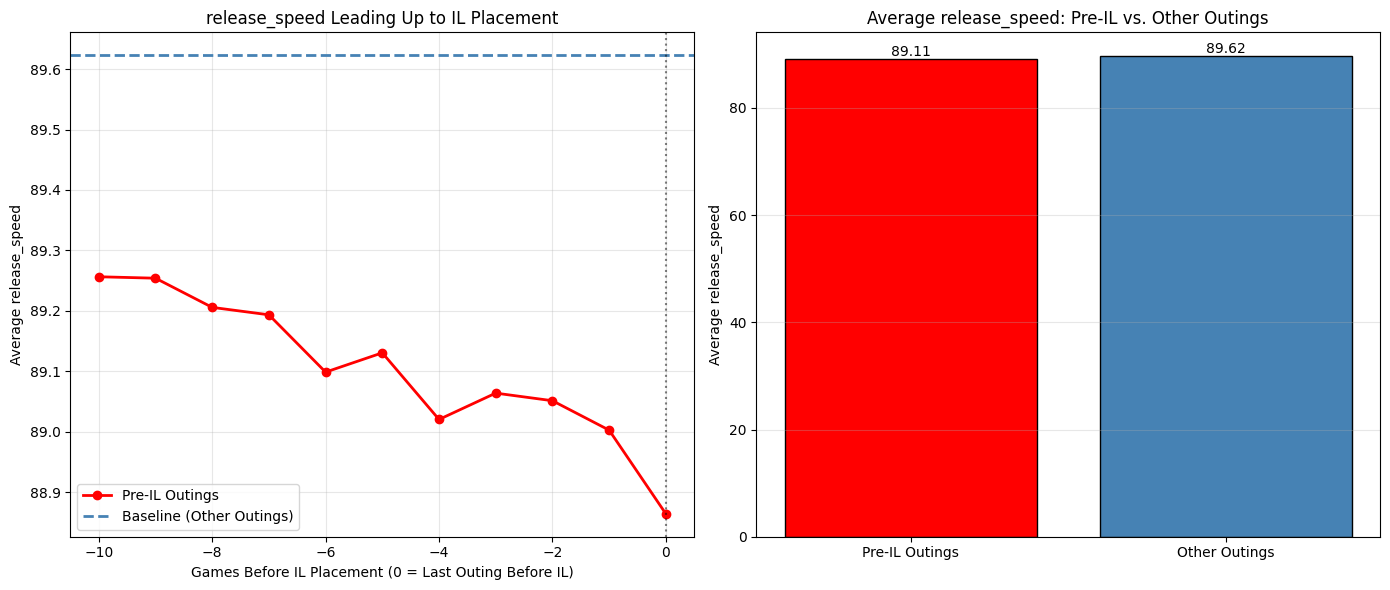

In [130]:
plot_metric_comparison(game_log_il, "release_speed", lag=10)

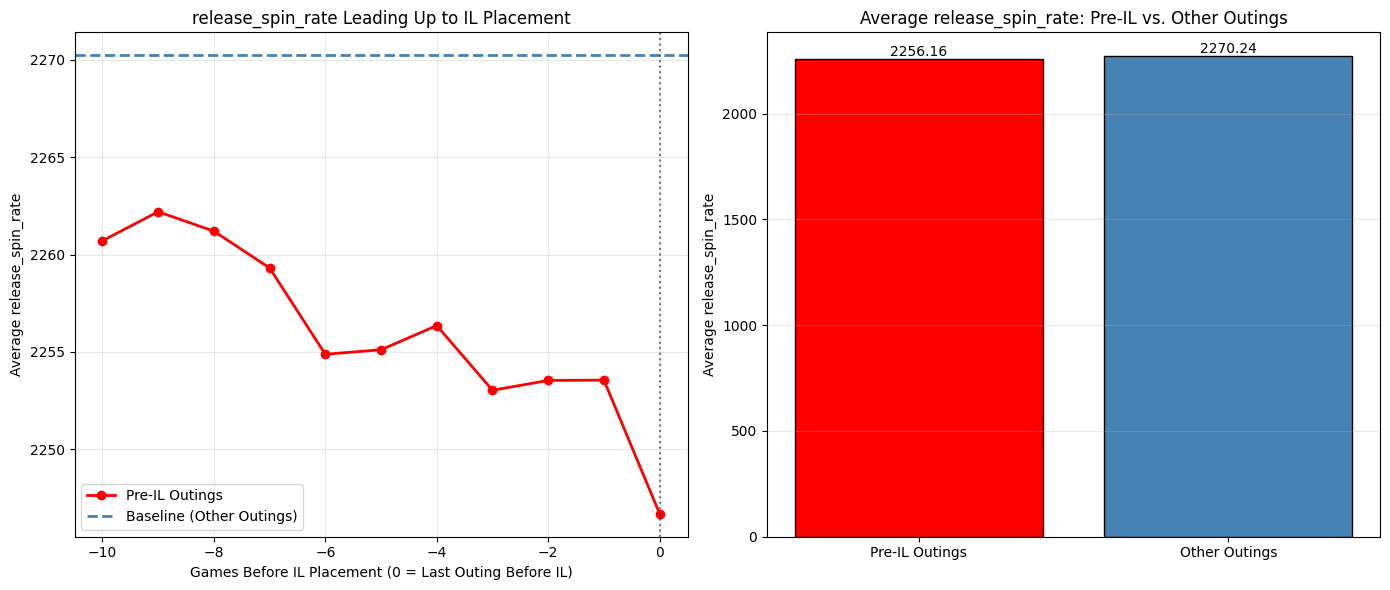

In [132]:
plot_metric_comparison(game_log_il, "release_spin_rate", lag=10)

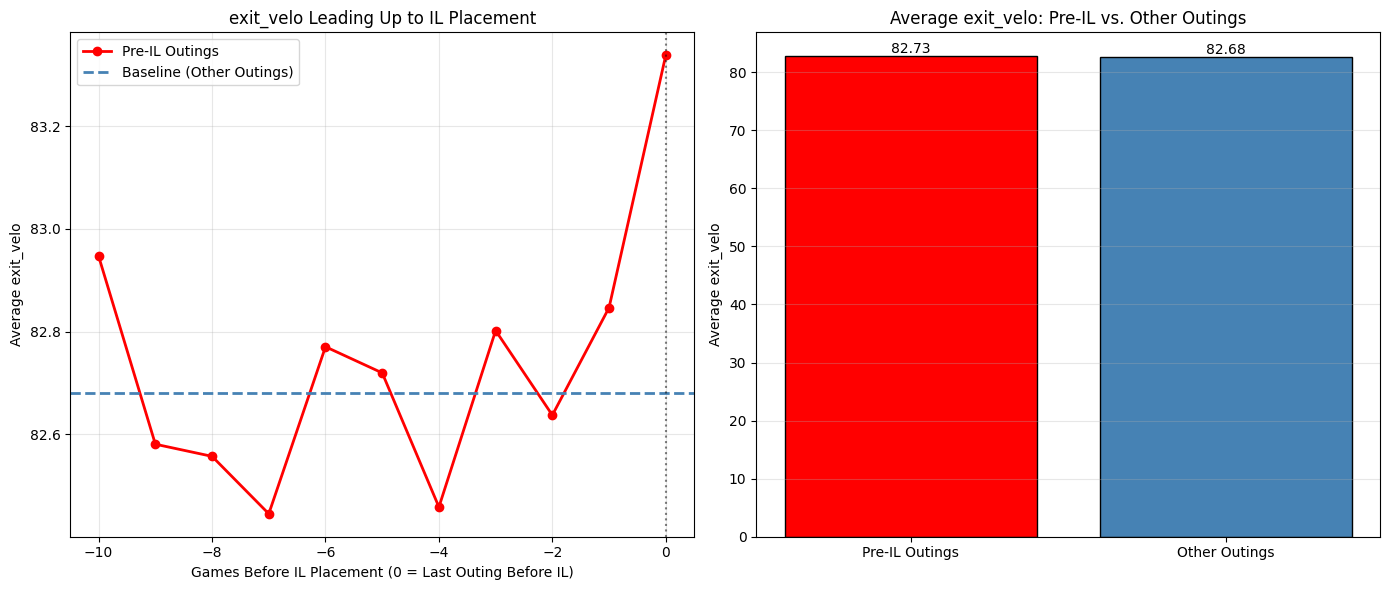

In [133]:
plot_metric_comparison(game_log_il, "exit_velo", lag=10)

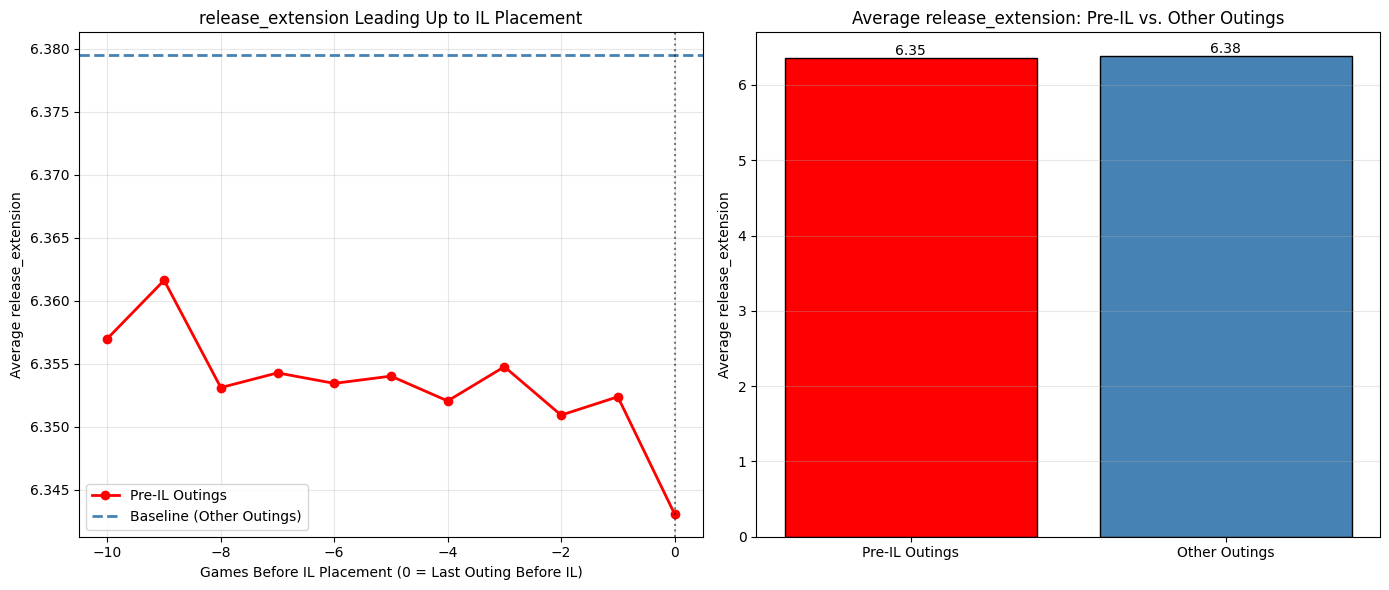

In [134]:
plot_metric_comparison(game_log_il, "release_extension", lag=10)

#### Regression Time


In [ ]:
game_log_il.columns

In [11]:
n_lag = 5

# ── Aggregate columns (always included) ──────────────────────────────────────
AGG_COLS = ["release_speed", "release_spin_rate"]

# ── Per-pitch-type columns: keep those present in data with ≥5% non-NaN rows ─
MIN_COVERAGE = 0.05   # pitch type must appear in at least 5% of games
pt_speed_cols = [f"release_speed_{pt}"     for pt in PITCH_TYPE_LABELS]
pt_spin_cols  = [f"release_spin_rate_{pt}" for pt in PITCH_TYPE_LABELS]

available_pt_cols = [
    col for col in pt_speed_cols + pt_spin_cols
    if col in game_log_il.columns and game_log_il[col].notna().mean() >= MIN_COVERAGE
]

print("Available pitch-type columns:")
for col in available_pt_cols:
    pct = game_log_il[col].notna().mean() * 100
    print(f"  {col:<30s}  {pct:.1f}% non-NaN")

x_columns = AGG_COLS + available_pt_cols
y_column = "is_pre_il_outing"

# Prepare data for logistic regression
logit_data = prepare_logit_data_with_lag(game_log_il, metrics=x_columns, n_lags=n_lag)
lag_cols = [f"{col}_lag_{lag}" for col in x_columns for lag in range(n_lag + 1)]
lag_cols = [c for c in lag_cols if c in logit_data.columns]
X = logit_data[lag_cols].fillna(0)
y = logit_data["target"]

print(f"\nX shape: {X.shape}  |  y shape: {y.shape}")
print(f"Features: {list(X.columns[:6])} ...")


In [12]:
# ── 1. Full model (aggregates + all pitch types) ─────────────────────────────
model_logit = sm.Logit(y, sm.add_constant(X))
result_logit = model_logit.fit(disp=False)
print("=== Full model (aggregate + per-pitch-type features) ===")
print(result_logit.summary())

# ── 2. Per-pitch-type models ──────────────────────────────────────────────────
# Group available pitch types from the column names, run a separate logit per type
pt_groups = {}
for col in available_pt_cols:
    # e.g. "release_speed_FF"  → pt = "FF"
    pt = col.rsplit("_", 1)[-1]
    pt_groups.setdefault(pt, []).append(col)

print("\n\n=== Per-Pitch-Type Logistic Regressions ===")
pt_results = {}
for pt, metrics in sorted(pt_groups.items()):
    lag_cols_pt = [f"{m}_lag_{lag}" for m in metrics for lag in range(n_lag + 1)]
    lag_cols_pt = [c for c in lag_cols_pt if c in logit_data.columns]
    X_pt = logit_data[lag_cols_pt].fillna(0)

    if X_pt.shape[1] == 0 or X_pt.isnull().all().all():
        print(f"  {pt}: insufficient data, skipping")
        continue

    try:
        m = sm.Logit(y, sm.add_constant(X_pt))
        r = m.fit(disp=False)
        pt_results[pt] = r
        label = PITCH_TYPE_LABELS.get(pt, pt)
        print(f"\n--- {label} ({pt}) ---")
        print(r.summary2().tables[1])   # just the coefficient table
    except Exception as e:
        print(f"  {pt}: model failed ({e})")


In [13]:
# Check assumptions of autocorrelation and multicollinearity
# Autocorrelation: Durbin-Watson test on residuals
residuals = result_logit.resid_response
dw_stat = sm.stats.durbin_watson(residuals)
print(f"Durbin-Watson statistic: {dw_stat:.3f} (values close to 2 suggest no autocorrelation)")

Durbin-Watson statistic: 0.001 (values close to 2 suggest no autocorrelation)


In [14]:
# Check for multicollinearity using VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print("\nVariance Inflation Factor (VIF) for features:")
print(vif_data)


Variance Inflation Factor (VIF) for features:
                    feature     VIF
0       release_speed_lag_0 168.362
1       release_speed_lag_1 180.330
2       release_speed_lag_2 182.946
3       release_speed_lag_3 184.386
4       release_speed_lag_4 181.254
5       release_speed_lag_5 168.031
6   release_spin_rate_lag_0 159.033
7   release_spin_rate_lag_1 167.121
8   release_spin_rate_lag_2 169.076
9   release_spin_rate_lag_3 170.077
10  release_spin_rate_lag_4 167.489
11  release_spin_rate_lag_5 157.690


#### Auto Regression bc it is Time-Series

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg, ar_select_order
from statsmodels.tsa.stattools import adfuller
from sktime.split import temporal_train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np


In [16]:
adfuller_result = adfuller(game_log_il['release_speed'].dropna())
print('ADF Statistic: %f' % adfuller_result[0])
print('p-value: %f' % adfuller_result[1])
print('Critical Values:')
for key, value in adfuller_result[4].items():
    print('\t%s: %.3f' % (key, value))

KeyboardInterrupt: 

In [18]:
X.head()

,release_speed_lag_0,release_speed_lag_1,release_speed_lag_2,release_speed_lag_3,release_speed_lag_4,release_speed_lag_5,release_spin_rate_lag_0,release_spin_rate_lag_1,release_spin_rate_lag_2,release_spin_rate_lag_3,release_spin_rate_lag_4,release_spin_rate_lag_5
0,90.181,87.129,88.010,89.030,89.306,89.329,2348.812,2217.571,2290.048,2354.739,2369.938,2276.167
1,91.700,87.667,92.427,92.520,92.485,91.129,2362.889,2553.000,2460.091,2226.286,2362.000,2352.548
2,93.922,90.630,91.686,91.338,92.978,91.040,2603.222,2632.400,2615.000,2540.952,2604.778,2594.267
3,91.588,0.000,0.000,0.000,0.000,0.000,2223.277,0.000,0.000,0.000,0.000,0.000
4,91.875,89.920,89.970,91.530,87.500,88.084,2306.500,2300.900,2334.150,2269.750,2153.750,2282.789


In [27]:
from statsmodels.tsa.api import VAR

# Use per-pitch-type speed + spin for the VAR (aggregate fallback if none available)
var_cols = [c for c in available_pt_cols if c in game_log_il.columns] or ["release_speed", "release_spin_rate"]

print(f"VAR series: {var_cols}")
original_df = game_log_il[var_cols].dropna(how="all")

model = VAR(original_df.dropna())
model_fit = model.fit(maxlags=5)
print(model_fit.summary())


In [28]:
from statsmodels.tsa.api import VAR
from statsmodels.stats.stattools import durbin_watson
import matplotlib.pyplot as plt

# Per-pitch-type series: drop columns with too many NaNs (keep ≥50% coverage)
var_cols = [
    c for c in available_pt_cols
    if c in game_log_il.columns and game_log_il[c].notna().mean() >= 0.5
] or ["release_speed", "release_spin_rate"]

print(f"VAR series ({len(var_cols)} columns):", var_cols)

original_df = game_log_il[var_cols].dropna()
print(f"Rows after dropna: {len(original_df)}")

model = VAR(original_df)
model_fit = model.fit(maxlags=5, ic="aic")

# ============================================
# 1. MODEL SUMMARY
# ============================================
print(model_fit.summary())

# ============================================
# 2. LAG ORDER SELECTION
# ============================================
print("\n--- Lag Order Selection ---")
lag_order = model.select_order(maxlags=10)
print(lag_order.summary())

# ============================================
# 3. GRANGER CAUSALITY TESTS (pitch-type pairs)
# ============================================
print("\n--- Granger Causality Tests ---")
speed_cols = [c for c in var_cols if c.startswith("release_speed_")]
spin_cols  = [c for c in var_cols if c.startswith("release_spin_rate_")]
for sp, sn in zip(speed_cols, spin_cols):
    pt = sp.rsplit("_", 1)[-1]
    label = PITCH_TYPE_LABELS.get(pt, pt)
    try:
        g1 = model_fit.test_causality(sp, sn, kind="f")
        g2 = model_fit.test_causality(sn, sp, kind="f")
        print(f"\n  [{label}] spin → speed:"); print(g1.summary())
        print(f"  [{label}] speed → spin:"); print(g2.summary())
    except Exception as e:
        print(f"  [{label}]: causality test failed ({e})")

# ============================================
# 4. DURBIN-WATSON
# ============================================
print("\n--- Durbin-Watson ---")
for col in model_fit.resid.columns:
    dw = durbin_watson(model_fit.resid[col])
    print(f"  {col}: {dw:.4f}")

# ============================================
# 5. NORMALITY
# ============================================
print("\n--- Normality Test ---")
print(model_fit.test_normality().summary())

# ============================================
# 6. WHITENESS
# ============================================
print("\n--- Whiteness Test ---")
print(model_fit.test_whiteness(nlags=10).summary())

# ============================================
# 7. STABILITY
# ============================================
print("\n--- Stability Check ---")
print("Is model stable?", model_fit.is_stable())

# ============================================
# 8. IMPULSE RESPONSE FUNCTION
# ============================================
irf = model_fit.irf(periods=10)
irf.plot()
plt.tight_layout()
plt.show()

# ============================================
# 9. FORECAST ERROR VARIANCE DECOMPOSITION
# ============================================
fevd = model_fit.fevd(periods=10)
fevd.plot()
plt.tight_layout()
plt.show()


## Below is some more analysis done by Claude 
---

In [21]:
# ── Distribution of days from last outing to IL placement ─────────────────────
days_series = pd.to_numeric(pre_il["days_outing_to_il"], errors="coerce").dropna()

print("=== Days from last outing to IL placement ===\n")
print(days_series.describe().round(1))
print()
print("Distribution by bucket:")
buckets = pd.cut(
    days_series,
    bins=[0, 1, 3, 7, 14, 21, 30, 45],
    labels=["Same day", "2–3d", "4–7d", "8–14d", "15–21d", "22–30d", "31–45d"],
)
print(buckets.value_counts().sort_index().to_string())

=== Days from last outing to IL placement ===

count   1975.000
mean       8.300
std       10.700
min        1.000
25%        2.000
50%        4.000
75%        9.000
max       45.000
Name: days_outing_to_il, dtype: float64

Distribution by bucket:
days_outing_to_il
Same day    462
2–3d        490
4–7d        489
8–14d       161
15–21d      101
22–30d      125
31–45d      147


In [22]:
# ── Pitchers with most IL stints in the dataset ───────────────────────────────
il_counts = (
    game_log_il[game_log_il["is_pre_il_outing"]]
    .groupby(["pitcher_name", "mlbam_id"])
    .agg(
        il_stints=("is_pre_il_outing", "sum"),
        il_types=("il_type", lambda x: x.value_counts().to_dict()),
    )
    .reset_index()
    .sort_values("il_stints", ascending=False)
    .head(25)
)
print("=== Pitchers with most IL placements (2021–2025) ===\n")
il_counts[["pitcher_name", "il_stints", "il_types"]]

=== Pitchers with most IL placements (2021–2025) ===



,pitcher_name,il_stints,il_types
397,Jon Gray,11,"{'10-day': 4, '15-day': 4, '60-day': 3}"
810,Zach Eflin,9,"{'15-day': 6, '10-day': 2, '60-day': 1}"
275,Garrett Whitlock,8,"{'15-day': 6, '10-day': 2}"
378,Joe Kelly,8,"{'15-day': 6, '10-day': 2}"
159,Colin Holderman,8,"{'15-day': 7, '60-day': 1}"
244,Edward Cabrera,8,"{'15-day': 7, '10-day': 1}"
24,Alex Cobb,8,"{'15-day': 5, '10-day': 3}"
433,Josh Staumont,7,"{'10-day': 3, '15-day': 3, '60-day': 1}"
708,Sonny Gray,7,"{'10-day': 4, '15-day': 3}"
401,Jordan Hicks,7,"{'15-day': 6, '60-day': 1}"


In [23]:
# ── Most common injury notes ──────────────────────────────────────────────────
injury_notes = (
    pre_il[pre_il["injury_note"].notna()]["injury_note"]
    .str.strip()
    .str.lower()
    .value_counts()
    .head(30)
)
print("=== Most common injury notes (pre-IL outings) ===\n")
injury_notes

=== Most common injury notes (pre-IL outings) ===



injury_note
                               297
right shoulder inflammation    102
right elbow inflammation        88
right shoulder strain           59
right forearm strain            38
left oblique strain             37
right shoulder impingement      34
left hamstring strain           34
left elbow inflammation         29
right oblique strain            28
right groin strain              27
left shoulder inflammation      26
right hamstring strain          26
right lat strain                25
low back strain                 22
right elbow sprain              17
left groin strain               17
right forearm inflammation      16
left shoulder impingement       16
right knee inflammation         15
left shoulder strain            15
right elbow discomfort          14
lower back strain               13
left forearm strain             12
neck strain                     12
right elbow strain              11
right shoulder fatigue          11
right calf strain               11
right tr

In [24]:
# ── Individual pitcher lookup ─────────────────────────────────────────────────
# Change this to any pitcher name (partial match, case-insensitive)
QUERY_PITCHER = "Gerrit Cole"

p_data = game_log_il[
    game_log_il["pitcher_name"].str.contains(QUERY_PITCHER, case=False, na=False)
].copy()

if p_data.empty:
    print(f"No data found for '{QUERY_PITCHER}'.")
else:
    print(f"Pitcher : {p_data['pitcher_name'].iloc[0]}")
    print(f"Seasons : {sorted(p_data['season'].unique())}")
    print(f"Outings : {len(p_data):,}")
    print(f"IL stints in dataset: {p_data['is_pre_il_outing'].sum()}")

    display_cols = [
        "game_date", "season", "ip", "n_pitches",
        "release_speed", "rp_consistency", "whiff_pct", "k_per_9", "bb_per_9",
        "is_pre_il_outing", "il_type", "days_outing_to_il", "injury_note"
    ]
    display_cols = [c for c in display_cols if c in p_data.columns]
    print()
    p_data[display_cols].tail(30)

Pitcher : Gerrit Cole
Seasons : [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Outings : 137
IL stints in dataset: 3



In [25]:
# ── Velocity trend: pre-IL outings vs. season avg for same pitcher/season ──────
# For each pre-IL outing, compute how the velocity on that outing compares
# to the pitcher's season average velocity.

season_velo = (
    game_log_il
    .groupby(["mlbam_id", "season"])["release_speed"]
    .mean()
    .reset_index()
    .rename(columns={"release_speed": "season_avg_velo"})
)

pre_il_velo = (
    pre_il[["mlbam_id", "pitcher_name", "season", "game_date", "release_speed",
             "il_type", "injury_note", "days_outing_to_il"]]
    .merge(season_velo, on=["mlbam_id", "season"], how="left")
)
pre_il_velo["velo_vs_season_avg"] = pre_il_velo["release_speed"] - pre_il_velo["season_avg_velo"]

print("=== Velocity delta on pre-IL outings (vs. pitcher's season average) ===\n")
print(pre_il_velo["velo_vs_season_avg"].describe().round(2))
print()
print("Breakdown by IL type:")
print(
    pre_il_velo.groupby("il_type")["velo_vs_season_avg"]
    .agg(["mean", "median", "std", "count"])
    .round(3)
    .to_string()
)

=== Velocity delta on pre-IL outings (vs. pitcher's season average) ===

count   1882.000
mean      -0.120
std        1.490
min       -8.660
25%       -0.950
50%       -0.100
75%        0.720
max        6.280
Name: velo_vs_season_avg, dtype: float64

Breakdown by IL type:
          mean  median   std  count
il_type                            
10-day  -0.036  -0.086 1.560    496
15-day  -0.105  -0.089 1.460    928
60-day  -0.238  -0.148 1.478    458


In [ ]:
# ── Release point consistency on pre-IL outings vs. season baseline ───────────
# Higher rp_consistency = more spread = worse consistency

season_rp = (
    game_log_il
    .groupby(["mlbam_id", "season"])["rp_consistency"]
    .mean()
    .reset_index()
    .rename(columns={"rp_consistency": "season_avg_rp"})
)

pre_il_rp = (
    pre_il[["mlbam_id", "pitcher_name", "season", "game_date", "rp_consistency",
             "il_type", "injury_note"]]
    .merge(season_rp, on=["mlbam_id", "season"], how="left")
)
pre_il_rp["rp_vs_season_avg"] = pre_il_rp["rp_consistency"] - pre_il_rp["season_avg_rp"]

print("=== Release-point spread delta on pre-IL outings (vs. season average) ===\n")
print("Positive = more spread than usual (worse consistency) on the pre-IL outing.\n")
print(pre_il_rp["rp_vs_season_avg"].describe().round(4))
print()
print("Breakdown by IL type:")
print(
    pre_il_rp.groupby("il_type")["rp_vs_season_avg"]
    .agg(["mean", "median", "std", "count"])
    .round(4)
    .to_string()
)

In [ ]:
# ── Season-by-season IL frequency ────────────────────────────────────────────
season_summary = (
    game_log_il
    .groupby("season")
    .agg(
        total_outings=("game_date", "count"),
        pre_il_outings=("is_pre_il_outing", "sum"),
        unique_pitchers=("mlbam_id", "nunique"),
    )
    .assign(
        il_pct=lambda df: (df["pre_il_outings"] / df["total_outings"] * 100).round(2)
    )
)
print("=== IL-preceding outings by season ===\n")
season_summary

---
## Notes

### Dataset
- **Pitcher selection**: Fangraphs `pitching_stats()` filtered to ≥ `MIN_G` games and ≥ `MIN_IP` IP. 
  Low thresholds are intentional — we want pitchers who got hurt early and may have fewer outings.
- **Grain**: One row per pitcher per game appearance (regular season and postseason if in Statcast).
- **Pitch metrics**: Simple means across all pitches thrown in the game.
- **Outcome metrics**: Computed using TBF as denominator for rate stats (same formulas as the app).

### IL enrichment
- Source: MLB Stats API (`/api/v1/transactions?sportId=1`). All transactions use `typeCode = "SC"`;
  IL type is parsed from the free-text `description` field.
- **Initial placements only**: Straight placements (`"placed on the X-day IL"`).
  Transfers to 60-day (`"transferred from 15-day to 60-day"`) are also included and flagged
  with `is_transfer_to_60 = True`.
- **Lookback window**: `MAX_DAYS_PRE_IL = 45` days. Outings more than 45 days before
  an IL placement are not tagged (likely a separate injury/off-season IL).
- **Multiple stints**: All IL placements for a pitcher are independently tagged — a pitcher
  with 3 IL stints will have up to 3 tagged rows.

### Known limitations
- Non-pitcher IL placements (position players, coaches) are filtered by MLBAM ID matching
  against our pitcher dataset — no position-field parsing needed.
- Retroactive IL placements (placed on IL for a game from a prior date) will appear with
  `days_outing_to_il = 0` or small values — this is expected behavior.
- Some pitchers may be in the IL dataset but not in our game log (e.g., injured in spring
  training, never appeared in a regular-season game that year) — these are silently skipped.
- The IL injury note is parsed from the last sentence of the transaction description.
  It is imperfect for multi-sentence descriptions.

### Re-running
To force a full re-fetch of any section, pass `force=True` to the relevant function:
```python
roster   = build_pitcher_roster(force=True)
errors   = run_statcast_fetch(roster, force=True)
game_log = build_master_game_log(roster, force=True)
il_df    = fetch_il_transactions(force=True)
```